# A6 domain time-course simulation — v5 template-transported coordinates

The cell-type model always uses the PCA coordinate systems learned during training.

For a region that changes shape, each current spatial location is first mapped back to the baseline region template by the inverse deformation. The transported template location is then projected by the saved PCA and saved scaling parameters:

\[
x_t
\longrightarrow
F_{r,t}^{-1}(x_t)
\longrightarrow
\text{saved PCA-relative coordinates}
\longrightarrow
P(C_t\mid r,\xi_t).
\]

No PCA is refitted at later time points.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import pickle
import joblib

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors


# ---------------- files ----------------
ADATA_PATH = Path("../adata_backup_with_pred_region_celltype.h5ad")
GENE_FITS_PATH = Path("../saved_models/gene_fit_results_A6.pkl")
CELLTYPE_MODEL_PATH = Path("../saved_models/celltype_mlp_state.pt")
CELLTYPE_PREPROCESS_PATH = Path("../saved_models/celltype_preprocess.joblib")

OUT_DIR = Path(
    "A6_domain_timecourse_v5_template_transported_coordinates"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------- user inputs ----------------
SLICE_ID = "A6"
ACTIVE_REGION = "12.0"
COLLISION_REGION = "13.0"
EXPECTED_CELLTYPE = "Ependymal"
PLOT_GENE = "Nnat"

TIMES = np.array([0.0, 0.5, 1.0])

# final active-region area = (1 + FINAL_AREA_GROWTH) × baseline area
FINAL_AREA_GROWTH = 2.00
MOVE_DIRECTION = f"toward:{COLLISION_REGION}"
MOVE_DISTANCE = 0.15

REGION_KEY = "pred_region"
CELLTYPE_KEY = "pred_celltype"
BATCH_KEY = "batch"

BASE_SEED = 20260622
CELLTYPE_SEED = 20260623


@dataclass(frozen=True)
class RegionAction:
    region: str
    final_area_growth: float
    direction: object
    move_distance: float


REGION_ACTIONS = [
    RegionAction(
        region=ACTIVE_REGION,
        final_area_growth=FINAL_AREA_GROWTH,
        direction=MOVE_DIRECTION,
        move_distance=MOVE_DISTANCE,
    )
]

In [2]:
# ---------- fixed-boundary domain evolution ----------
def smoothstep(t):
    t = np.clip(float(t), 0.0, 1.0)
    return 3.0 * t**2 - 2.0 * t**3


def sorted_labels(values):
    def key(x):
        try:
            return (0, float(x))
        except (TypeError, ValueError):
            return (1, str(x))
    return sorted(map(str, values), key=key)


def local_area_weights(xy, k=6):
    k = min(max(3, k), len(xy))
    d = NearestNeighbors(n_neighbors=k).fit(xy).kneighbors(
        xy, return_distance=True
    )[0][:, -1]
    return np.maximum(d, 1e-10) ** 2


def signed_distance_fields(xy, labels, levels):
    fields = np.empty((len(xy), len(levels)))

    for j, region in enumerate(levels):
        inside = labels == region
        outside = ~inside

        d_inside = NearestNeighbors(n_neighbors=1).fit(
            xy[inside]
        ).kneighbors(xy, return_distance=True)[0][:, 0]

        d_outside = NearestNeighbors(n_neighbors=1).fit(
            xy[outside]
        ).kneighbors(xy, return_distance=True)[0][:, 0]

        fields[:, j] = d_outside - d_inside

    return fields


def direction_vector(spec, region, centers):
    if spec is None:
        return np.zeros(2)

    if isinstance(spec, str):
        cardinal = {
            "left": np.array([-1.0, 0.0]),
            "right": np.array([1.0, 0.0]),
            "up": np.array([0.0, -1.0]),
            "down": np.array([0.0, 1.0]),
        }

        if spec in cardinal:
            vector = cardinal[spec]
        elif spec.startswith("toward:"):
            target = spec.split(":", 1)[1]
            vector = centers[target] - centers[region]
        elif spec.startswith("away:"):
            target = spec.split(":", 1)[1]
            vector = centers[region] - centers[target]
        else:
            raise ValueError(f"Unsupported direction: {spec}")
    else:
        vector = np.asarray(spec, dtype=float)

    return vector / max(np.linalg.norm(vector), 1e-12)


def interpolate_field(model, query, field):
    distance, index = model.kneighbors(
        query, return_distance=True
    )
    weight = 1.0 / np.maximum(distance, 1e-10) ** 2
    weight /= weight.sum(axis=1, keepdims=True)
    return np.sum(weight * field[index], axis=1)


def action_state(action, t, xy, centers):
    g = smoothstep(t)
    area_multiplier = 1.0 + action.final_area_growth * g
    spatial_scale = np.sqrt(area_multiplier)
    tissue_scale = min(np.ptp(xy[:, 0]), np.ptp(xy[:, 1]))

    shift = (
        g
        * action.move_distance
        * tissue_scale
        * direction_vector(
            action.direction,
            str(action.region),
            centers,
        )
    )

    return {
        "center": centers[str(action.region)].copy(),
        "scale": float(spatial_scale),
        "shift": np.asarray(shift, dtype=float),
        "area_multiplier": float(area_multiplier),
    }


def inverse_transport_xy(xy_current, state):
    center = state["center"]
    return (
        center
        + (
            xy_current
            - (center + state["shift"])
        )
        / state["scale"]
    )


def generate_domain_trajectory(
    xy,
    baseline_labels,
    actions,
    times,
    weights,
):
    baseline_labels = np.asarray(baseline_labels).astype(str)
    levels = sorted_labels(pd.unique(baseline_labels))
    level_index = {region: j for j, region in enumerate(levels)}

    centers = {
        region: xy[baseline_labels == region].mean(axis=0)
        for region in levels
    }
    baseline_area = {
        region: weights[baseline_labels == region].sum()
        for region in levels
    }

    base_fields = signed_distance_fields(
        xy, baseline_labels, levels
    )
    interpolator = NearestNeighbors(
        n_neighbors=min(12, len(xy))
    ).fit(xy)

    labels_by_time = []
    transports_by_time = []

    for t in times:
        transport_t = {
            str(action.region): action_state(
                action, t, xy, centers
            )
            for action in actions
        }
        transports_by_time.append(transport_t)

        if np.isclose(t, 0.0):
            labels_by_time.append(baseline_labels.copy())
            continue

        scores = base_fields.copy()
        target_areas = {}

        for action in actions:
            region = str(action.region)
            j = level_index[region]
            state = transport_t[region]

            template_xy = inverse_transport_xy(xy, state)
            scores[:, j] = interpolate_field(
                interpolator,
                template_xy,
                base_fields[:, j],
            )
            target_areas[region] = (
                baseline_area[region]
                * state["area_multiplier"]
            )

        biases = np.zeros(len(levels))

        for _ in range(8):
            for region, target_area in target_areas.items():
                j = level_index[region]
                adjusted = scores + biases[None, :]
                other = np.delete(adjusted, j, axis=1).max(axis=1)
                margin = other - scores[:, j]

                lo, hi = margin.min(), margin.max()
                for _ in range(45):
                    mid = 0.5 * (lo + hi)
                    won_area = weights[margin <= mid].sum()
                    if won_area < target_area:
                        lo = mid
                    else:
                        hi = mid

                biases[j] = 0.5 * (lo + hi)

        labels_t = np.asarray(levels)[
            np.argmax(scores + biases[None, :], axis=1)
        ]
        labels_by_time.append(labels_t)

    return (
        labels_by_time,
        transports_by_time,
        levels,
    )

In [3]:
# ---------- saved PCA template coordinates and cell-type model ----------
class SpatialProbMLP(nn.Module):
    def __init__(self, input_dim, n_celltypes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, n_celltypes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x), dim=1)


def load_celltype_model():
    prep = joblib.load(CELLTYPE_PREPROCESS_PATH)

    prep["region_categories"] = list(
        map(str, prep["region_categories"])
    )
    prep["celltype_names"] = [
        str(name).replace("prob_", "")
        for name in prep["prob_cols"]
    ]
    prep["reference_transforms"] = {
        str(region): transform
        for region, transform in prep[
            "region_coordinate_transforms"
        ].items()
    }

    model = SpatialProbMLP(
        int(prep["input_dim"]),
        int(prep["n_celltypes"]),
    )

    try:
        state = torch.load(
            CELLTYPE_MODEL_PATH,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        state = torch.load(
            CELLTYPE_MODEL_PATH,
            map_location="cpu",
        )

    model.load_state_dict(state)
    model.eval()
    return model, prep


def transported_celltype_features(
    coords_3d,
    current_regions,
    transport_t,
    prep,
):
    """
    Map current cells back to each region's baseline template,
    then apply the PCA and scaling saved during model training.
    """
    coords_3d = np.asarray(coords_3d, dtype=float)
    current_regions = np.asarray(current_regions).astype(str)

    categories = prep["region_categories"]
    category_index = {
        region: j for j, region in enumerate(categories)
    }
    transforms = prep["reference_transforms"]

    relative = np.zeros((len(coords_3d), 3), dtype=float)

    for region in np.unique(current_regions):
        if region not in transforms:
            raise KeyError(
                f"No saved PCA transform for region {region}."
            )

        mask = current_regions == region
        template_xyz = coords_3d[mask].copy()

        # Active regions are mapped back by the exact inverse deformation.
        # Regions without an action use the identity map.
        if region in transport_t:
            template_xyz[:, :2] = inverse_transport_xy(
                template_xyz[:, :2],
                transport_t[region],
            )

        transform = transforms[region]
        pca = transform["pca"]

        if pca is None:
            projected = template_xyz
        else:
            projected = pca.transform(template_xyz)

        minimum = np.asarray(
            transform["min_xyz"], dtype=float
        )
        span = np.asarray(
            transform["scale"], dtype=float
        )
        span = np.where(span < 1e-6, 1.0, span)

        relative[mask] = np.clip(
            2.0 * (projected - minimum) / span - 1.0,
            -1.0,
            1.0,
        )

    onehot = np.zeros(
        (len(coords_3d), len(categories)),
        dtype=float,
    )
    for i, region in enumerate(current_regions):
        onehot[i, category_index[region]] = 1.0

    features = np.c_[relative, onehot]

    if features.shape[1] != int(prep["input_dim"]):
        raise ValueError(
            "Cell-type feature dimension does not match "
            "the saved model."
        )

    return features, relative


def sample_celltypes(probabilities, names, seed):
    rng = np.random.default_rng(seed)
    cumulative = np.cumsum(probabilities, axis=1)
    draw = rng.random(len(probabilities))
    index = (draw[:, None] > cumulative).sum(axis=1)
    index = np.minimum(index, len(names) - 1)
    return np.asarray(names)[index]


def regenerate_relevant_celltypes(
    baseline_celltypes,
    baseline_regions,
    current_regions,
    probabilities,
    celltype_names,
    active_regions,
    seed,
):
    """
    Resample:
    1. all cells currently inside an actively deformed region;
    2. all cells whose region label changed.

    Unaffected cells retain their baseline cell type.
    """
    changed_region = current_regions != baseline_regions
    update = (
        changed_region
        | np.isin(current_regions, active_regions)
    )

    result = baseline_celltypes.copy()
    sampled = sample_celltypes(
        probabilities,
        celltype_names,
        seed,
    )
    result[update] = sampled[update]
    return result

In [4]:
# ---------- generate region and cell-type trajectories ----------
adata = sc.read(ADATA_PATH)

with open(GENE_FITS_PATH, "rb") as handle:
    gene_bundle = pickle.load(handle)

celltype_model, celltype_prep = load_celltype_model()

a6 = adata[
    adata.obs[BATCH_KEY].astype(str) == SLICE_ID
].copy()

saved_obs = list(map(str, gene_bundle["obs_names"]))
a6 = a6[saved_obs].copy()

spatial_key = str(celltype_prep["spatial_key"])
coords_3d = np.asarray(
    a6.obsm[spatial_key][:, :3],
    dtype=float,
)
xy = coords_3d[:, :2]

baseline_regions = (
    a6.obs[REGION_KEY].astype(str).to_numpy()
)
baseline_celltypes = (
    a6.obs[CELLTYPE_KEY].astype(str).to_numpy()
)

weights = local_area_weights(xy)

(
    regions_by_time,
    transports_by_time,
    region_levels,
) = generate_domain_trajectory(
    xy=xy,
    baseline_labels=baseline_regions,
    actions=REGION_ACTIONS,
    times=TIMES,
    weights=weights,
)

celltype_names = np.asarray(
    celltype_prep["celltype_names"]
)
active_regions = [
    str(action.region)
    for action in REGION_ACTIONS
]

probabilities_by_time = []
relative_coordinates_by_time = []
celltypes_by_time = []

for h, (
    t,
    regions_t,
    transport_t,
) in enumerate(
    zip(
        TIMES,
        regions_by_time,
        transports_by_time,
    )
):
    features_t, relative_t = transported_celltype_features(
        coords_3d=coords_3d,
        current_regions=regions_t,
        transport_t=transport_t,
        prep=celltype_prep,
    )

    with torch.no_grad():
        probabilities_t = celltype_model(
            torch.tensor(
                features_t,
                dtype=torch.float32,
            )
        ).cpu().numpy()

    probabilities_t /= np.maximum(
        probabilities_t.sum(axis=1, keepdims=True),
        1e-12,
    )

    if np.isclose(t, 0.0):
        celltypes_t = baseline_celltypes.copy()
    else:
        celltypes_t = regenerate_relevant_celltypes(
            baseline_celltypes=baseline_celltypes,
            baseline_regions=baseline_regions,
            current_regions=regions_t,
            probabilities=probabilities_t,
            celltype_names=celltype_names,
            active_regions=active_regions,
            seed=CELLTYPE_SEED + 10_000 * h,
        )

    probabilities_by_time.append(probabilities_t)
    relative_coordinates_by_time.append(relative_t)
    celltypes_by_time.append(celltypes_t)

In [5]:
# ---------- update gene design and simulate NB expression ----------
genes = a6.var_names.astype(str).tolist()
X0 = np.asarray(gene_bundle["X"], dtype=float)
X_columns = list(map(str, gene_bundle["X_columns"]))
offset = np.asarray(gene_bundle["offset"], dtype=float)

domain_columns = {
    region: X_columns.index(region)
    for region in region_levels
    if region in X_columns
}
celltype_columns = {
    celltype: X_columns.index(celltype)
    for celltype in celltype_names
    if celltype in X_columns
}

X_by_time = []

for regions_t, celltypes_t in zip(
    regions_by_time,
    celltypes_by_time,
):
    Xt = X0.copy()

    for region, column in domain_columns.items():
        Xt[:, column] = (
            regions_t == region
        ).astype(float)

    for celltype, column in celltype_columns.items():
        Xt[:, column] = (
            celltypes_t == celltype
        ).astype(float)

    X_by_time.append(Xt)


counts_by_time = [
    np.zeros((a6.n_obs, len(genes)), dtype=np.int32)
    for _ in TIMES
]

for gene_index, gene in enumerate(genes):
    fit = gene_bundle["fits"].get(gene)

    if (
        not isinstance(fit, dict)
        or "beta" not in fit
        or "alpha" not in fit
    ):
        continue

    beta = np.asarray(fit["beta"], dtype=float)
    alpha = max(float(fit["alpha"]), 1e-8)
    size = 1.0 / alpha

    for time_index, Xt in enumerate(X_by_time):
        mu = np.exp(
            np.clip(Xt @ beta + offset, -20, 20)
        )
        probability = np.clip(
            size / (size + mu),
            1e-12,
            1.0 - 1e-12,
        )

        rng = np.random.default_rng(
            BASE_SEED
            + 100_000 * time_index
            + gene_index
        )
        counts_by_time[time_index][:, gene_index] = (
            rng.negative_binomial(
                size,
                probability,
            ).astype(np.int32)
        )


gene_index = genes.index(PLOT_GENE)
gene_fit = gene_bundle["fits"].get(PLOT_GENE)
if not isinstance(gene_fit, dict):
    raise ValueError(
        f"No successful saved fit for {PLOT_GENE}."
    )

gene_beta = np.asarray(
    gene_fit["beta"],
    dtype=float,
)
gene_mu_by_time = [
    np.exp(
        np.clip(Xt @ gene_beta + offset, -20, 20)
    )
    for Xt in X_by_time
]

,time,changed_region_count,changed_celltype_count,active_region_area_ratio,collision_region_area_ratio,Ependymal_area_ratio,Ependymal_proportion_in_active_region,Nnat_expected_mean_in_active_region
0,0.0,0,0,1.0000,1.0000,1.0000,0.5872,0.4535
1,0.5,260,398,1.9988,1.0000,1.3287,0.4768,0.2884
2,1.0,499,581,3.0012,0.6118,1.7926,0.4614,0.3824


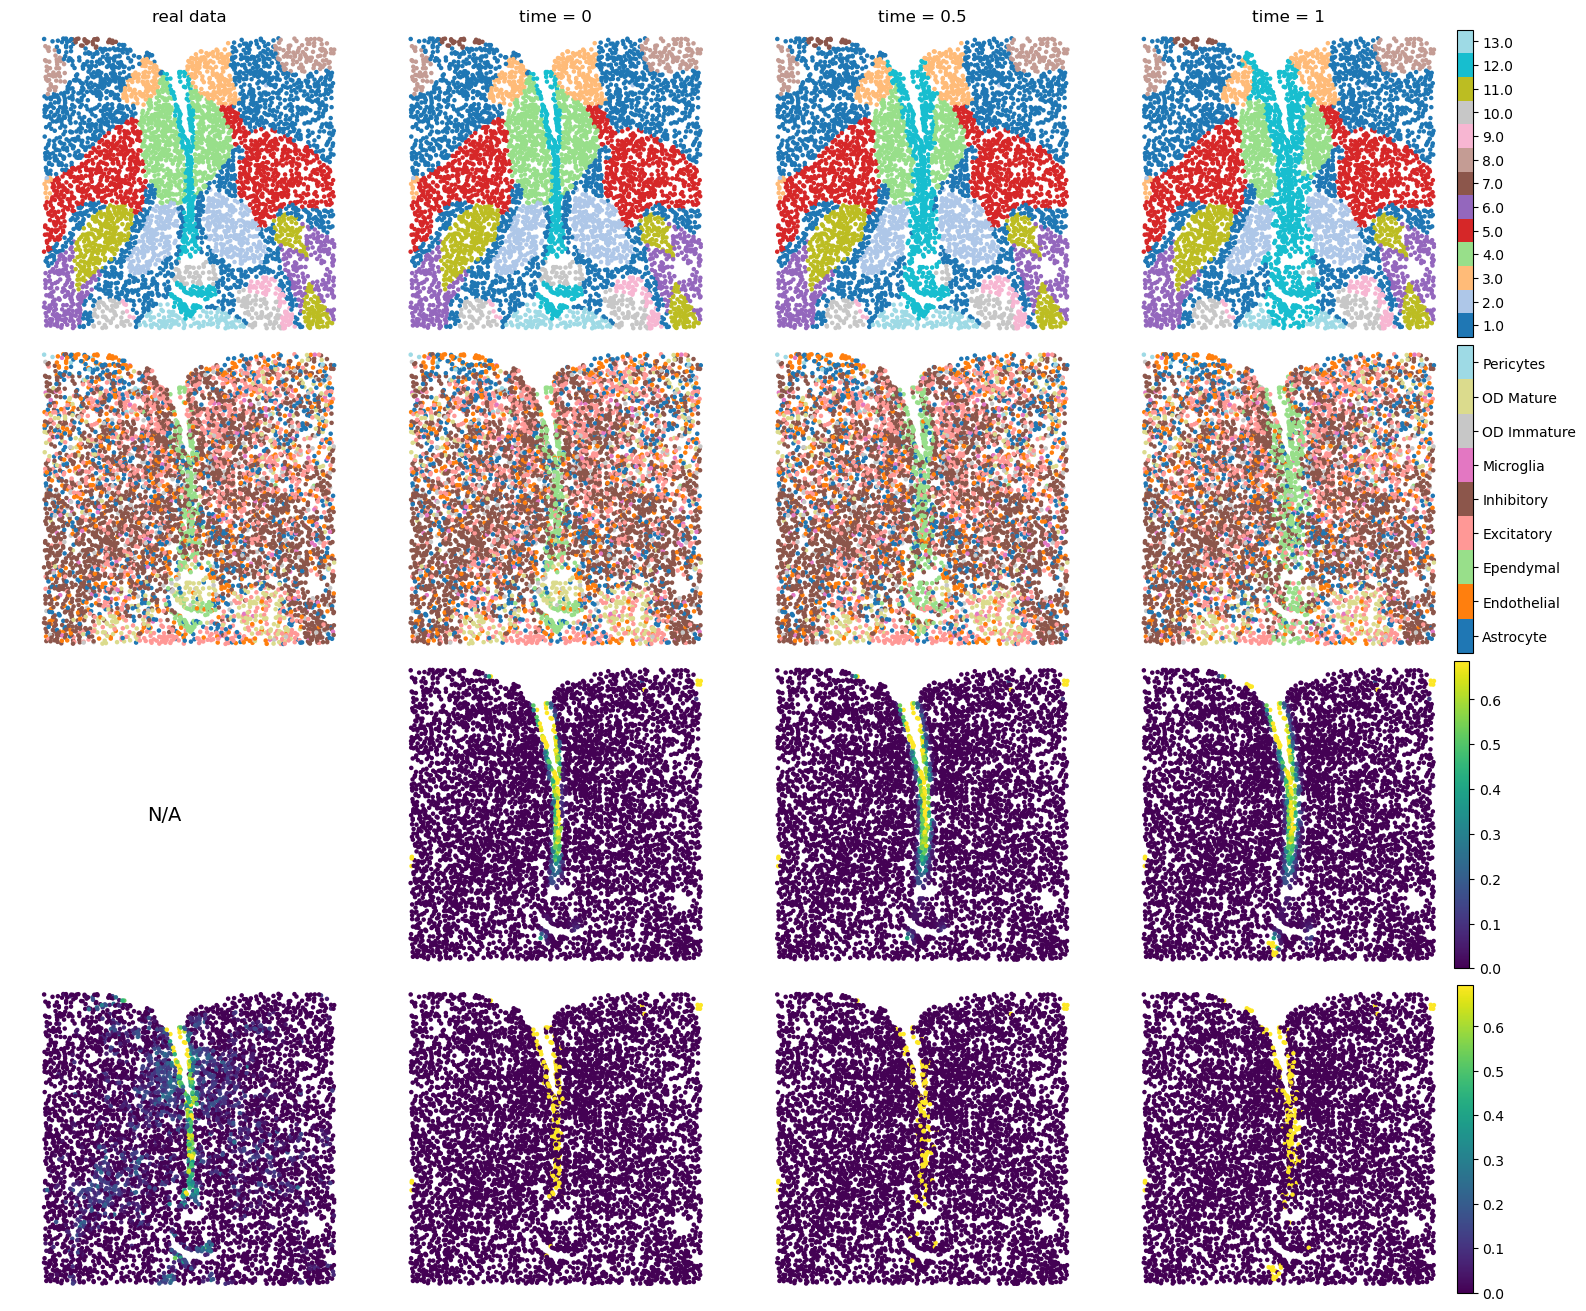

In [6]:
# ---------- core summary and visualization ----------
baseline_region_area = {
    region: weights[baseline_regions == region].sum()
    for region in region_levels
}
baseline_celltype_area = weights[
    baseline_celltypes == EXPECTED_CELLTYPE
].sum()

summary_rows = []

for h, t in enumerate(TIMES):
    active_mask = regions_by_time[h] == ACTIVE_REGION
    collision_mask = (
        regions_by_time[h] == COLLISION_REGION
    )
    expected_mask = (
        celltypes_by_time[h] == EXPECTED_CELLTYPE
    )

    summary_rows.append({
        "time": float(t),
        "changed_region_count": int(
            np.sum(
                regions_by_time[h]
                != baseline_regions
            )
        ),
        "changed_celltype_count": int(
            np.sum(
                celltypes_by_time[h]
                != baseline_celltypes
            )
        ),
        "active_region_area_ratio": float(
            weights[active_mask].sum()
            / baseline_region_area[ACTIVE_REGION]
        ),
        "collision_region_area_ratio": float(
            weights[collision_mask].sum()
            / baseline_region_area[COLLISION_REGION]
        ),
        f"{EXPECTED_CELLTYPE}_area_ratio": float(
            weights[expected_mask].sum()
            / baseline_celltype_area
        ),
        f"{EXPECTED_CELLTYPE}_proportion_in_active_region": float(
            expected_mask[active_mask].mean()
        ),
        f"{PLOT_GENE}_expected_mean_in_active_region": float(
            gene_mu_by_time[h][active_mask].mean()
        ),
    })

summary = pd.DataFrame(summary_rows)
display(summary.round(4))


# ---------- real data Nnat expression ----------
if "counts" in a6.layers:
    real_counts_mat = a6.layers["counts"]
else:
    real_counts_mat = a6.X

if hasattr(real_counts_mat, "toarray"):
    real_gene_values = np.log1p(
        np.asarray(real_counts_mat[:, gene_index].toarray()).ravel()
    )
else:
    real_gene_values = np.log1p(
        np.asarray(real_counts_mat[:, gene_index]).ravel()
    )


region_cmap = ListedColormap(
    plt.cm.tab20(
        np.linspace(0, 1, len(region_levels))
    )
)
celltype_levels = sorted_labels(celltype_names)
celltype_cmap = ListedColormap(
    plt.cm.tab20(
        np.linspace(0, 1, len(celltype_levels))
    )
)

expected_gene = [
    np.log1p(mu)
    for mu in gene_mu_by_time
]
sampled_gene = [
    np.log1p(counts[:, gene_index])
    for counts in counts_by_time
]

expected_vmax = np.percentile(
    np.concatenate(expected_gene),
    99,
)
sampled_vmax = np.percentile(
    np.concatenate([real_gene_values] + sampled_gene),
    99,
)

x_padding = 0.03 * np.ptp(xy[:, 0])
y_padding = 0.03 * np.ptp(xy[:, 1])
x_limits = (
    xy[:, 0].min() - x_padding,
    xy[:, 0].max() + x_padding,
)
y_limits = (
    xy[:, 1].max() + y_padding,
    xy[:, 1].min() - y_padding,
)

ncols = len(TIMES) + 1  # one extra column for real data
fig, axes = plt.subplots(
    4,
    ncols,
    figsize=(16, 13),
    constrained_layout=True,
)

# ===== first column: real data =====
real_region_code = pd.Categorical(
    baseline_regions,
    categories=region_levels,
).codes

real_celltype_code = pd.Categorical(
    baseline_celltypes,
    categories=celltype_levels,
).codes

real_region_scatter = axes[0, 0].scatter(
    xy[:, 0],
    xy[:, 1],
    c=real_region_code,
    s=5,
    cmap=region_cmap,
    vmin=-0.5,
    vmax=len(region_levels) - 0.5,
)

real_celltype_scatter = axes[1, 0].scatter(
    xy[:, 0],
    xy[:, 1],
    c=real_celltype_code,
    s=5,
    cmap=celltype_cmap,
    vmin=-0.5,
    vmax=len(celltype_levels) - 0.5,
)

# row 3: no expected expression for real data
axes[2, 0].text(
    0.5, 0.5, "N/A",
    ha="center", va="center",
    fontsize=14,
    transform=axes[2, 0].transAxes
)

real_gene_scatter = axes[3, 0].scatter(
    xy[:, 0],
    xy[:, 1],
    c=real_gene_values,
    s=5,
    cmap="viridis",
    vmin=0,
    vmax=sampled_vmax,
)

axes[0, 0].set_title("real data")

for ax in axes[:, 0]:
    ax.set_aspect("equal")
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.axis("off")


# ===== remaining columns: simulated time points =====
for h, t in enumerate(TIMES, start=1):
    idx = h - 1

    region_code = pd.Categorical(
        regions_by_time[idx],
        categories=region_levels,
    ).codes
    celltype_code = pd.Categorical(
        celltypes_by_time[idx],
        categories=celltype_levels,
    ).codes

    region_scatter = axes[0, h].scatter(
        xy[:, 0],
        xy[:, 1],
        c=region_code,
        s=5,
        cmap=region_cmap,
        vmin=-0.5,
        vmax=len(region_levels) - 0.5,
    )
    celltype_scatter = axes[1, h].scatter(
        xy[:, 0],
        xy[:, 1],
        c=celltype_code,
        s=5,
        cmap=celltype_cmap,
        vmin=-0.5,
        vmax=len(celltype_levels) - 0.5,
    )
    expected_scatter = axes[2, h].scatter(
        xy[:, 0],
        xy[:, 1],
        c=expected_gene[idx],
        s=5,
        cmap="viridis",
        vmin=0,
        vmax=expected_vmax,
    )
    sampled_scatter = axes[3, h].scatter(
        xy[:, 0],
        xy[:, 1],
        c=sampled_gene[idx],
        s=5,
        cmap="viridis",
        vmin=0,
        vmax=sampled_vmax,
    )

    axes[0, h].set_title(f"time = {t:g}")

    for ax in axes[:, h]:
        ax.set_aspect("equal")
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)
        ax.axis("off")


# ===== row labels =====
axes[0, 0].set_ylabel("Region", fontsize=12)
axes[1, 0].set_ylabel("Cell type", fontsize=12)
axes[2, 0].set_ylabel(f"log1p(E[{PLOT_GENE}])", fontsize=12)
axes[3, 0].set_ylabel(f"log1p({PLOT_GENE} expression)", fontsize=12)


# ===== colorbars =====
region_colorbar = fig.colorbar(
    region_scatter,
    ax=axes[0, :],
    fraction=0.018,
    pad=0.01,
    ticks=np.arange(len(region_levels)),
)
region_colorbar.ax.set_yticklabels(region_levels)

celltype_colorbar = fig.colorbar(
    celltype_scatter,
    ax=axes[1, :],
    fraction=0.018,
    pad=0.01,
    ticks=np.arange(len(celltype_levels)),
)
celltype_colorbar.ax.set_yticklabels(celltype_levels)

fig.colorbar(
    expected_scatter,
    ax=axes[2, 1:],
    fraction=0.018,
    pad=0.01,
)

fig.colorbar(
    real_gene_scatter,
    ax=axes[3, :],
    fraction=0.018,
    pad=0.01,
)

plt.savefig(
    OUT_DIR / "A6_template_transported_maps_with_real.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

In [ ]:
# ---------- save outputs ----------
snapshots = {}

for h, t in enumerate(TIMES):
    obs = a6.obs.copy()
    obs["time"] = float(t)
    obs["baseline_region"] = baseline_regions
    obs["baseline_celltype"] = baseline_celltypes
    obs[REGION_KEY] = regions_by_time[h]
    obs[CELLTYPE_KEY] = celltypes_by_time[h]

    count_matrix = csr_matrix(counts_by_time[h])

    snapshot = ad.AnnData(
        X=count_matrix,
        obs=obs,
        var=a6.var.copy(),
    )
    snapshot.layers["counts"] = count_matrix.copy()
    snapshot.obsm["spatial_3d"] = coords_3d.copy()
    snapshot.obsm[
        "celltype_template_relative_coordinates"
    ] = relative_coordinates_by_time[h].astype(np.float32)
    snapshot.obsm["pred_celltype_proba"] = (
        probabilities_by_time[h].astype(np.float32)
    )
    snapshot.uns["pred_celltype_names"] = (
        celltype_names.astype(str)
    )

    snapshots[f"t{t:g}"] = snapshot

synthetic = ad.concat(
    snapshots,
    label="timepoint",
    index_unique="-",
)

synthetic.write_h5ad(
    OUT_DIR
    / "A6_domain_timecourse_v5_template_transported.h5ad"
)
summary.to_csv(
    OUT_DIR / "A6_template_transported_summary.csv",
    index=False,
)

print("Saved to:", OUT_DIR.resolve())